# Ajuste de taxas de transfência não radiativa 

O sistema de EDO que contém os parâmetros de interesse é

\begin{equation}
\begin{aligned}
    \dot{n}_5
    &=
    \sigma P F(t)\, n_4
    - W_{51} n_1 n_5
    - W_{52} n_2 n_5
    - k_{54} n_5 
    \\
     \dot{n}_4
    &= -\dot{n_5} 
    \\
    \dot{n}_3
    &=
    W_{52} n_2 n_5
    - k_{31} n_3 
    \\
    \dot{n}_2
    &=
    W_{51} n_1 n_5
    - W_{52} n_2 n_5
    - k_{21} n_2 \\
    \dot{n}_1 &= -(\dot{n}_2 + \dot{n}_3)    
\end{aligned} .
\end{equation}

Adimensionalizando a concentração por $n_0 = n_1(0) + n_4(0)$ e o tempo por $\tau = 1/f$, obtemos

\begin{aligned}
\dot{x_5}(\tau)
&=
\Pi F(\tau) x_4
- W'_{51} x_5
- W'_{52} x_2 x_5
- k'_{54} x_5
\\
\dot{x_4}(\tau)
&= - \dot{x_5}
\\
\dot{x_3}(\tau)
&=
W'_{52} x_2 x_5
- k'_{31} x_3 \\
\dot{x_2}(\tau)
&=
W'_{51} x_5
- W'_{52} x_2 x_5
- k'_{21} x_2
\\
\dot{x_1}(\tau)
&= -(\dot{x_3} + \dot{x_2})
\end{aligned},
onde 

### Preamble and experimental data

In [12]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from random import random
import os

# from treament_tcspc_data import fetch_data_filenames, extract_data_info_from_path, time_domain_visual_verification
# from snr_aux_functions import get_snr_db, plot_time_and_freq_domain

In [13]:
# Phase difference list, processed previously
pd_list = np.load("./phase_difference_list.npy")

In [14]:
#--------------------------------------
# Estimations of n1 and n4
#--------------------------------------
dens_y2o3 = 5.010 #g/cm^3
massa_molar_y2o3 = 225.81 #g/mol
frac_er = 0.005 # Er3+ percentage in the sample
frac_yb = 0.015 # Yb3+ percentage in the sample

n1_0 = (dens_y2o3/massa_molar_y2o3)*(6.022e23)*2*(frac_er) # number of Er3+ ions 
n4_0 = (dens_y2o3/massa_molar_y2o3)*(6.022e23)*2*(frac_yb) # number of Yb3+ ions

n0 = n1_0 + n4_0

In [15]:
#--------------------------------------
# Parameters
#--------------------------------------
k21 = 16.66   # s^-1, Tab. 2 em https://doi.org/10.1063/1.2739301
k31 = 17237.7 # s^-1
k54 = 1279.0  # Tab. 2 Lu0 em https://doi.org/10.1016/j.jallcom.2021.159227
sigma = 1.75e-20 # # Supporting Information, page S5, Labrador

P = 1e23#estimated from experiment is 1e24 #Photons/(cm³ * s), from measurements
# P = 1e20#5.4e20    # fótons / (cm^2 * s) (baseado em 110 W/cm^2 do paper de Labrador)

#====================================================
# Some constants
#====================================================
# ww51 = 1e-10#8.192933479247868e-09 # chute incial
# ww52 = 1e-10#1.9970817793515877e-07 # chute inicial
ww51 = 1.0e-11
ww52 = 1.0e-11
#====================================================

#====================================================
# Excitation modulation paramenters
#====================================================
amplitude = 0.5
offset = 0.5
#====================================================


In [16]:
# 3. Função para Extrair a Fase via FFT
def extrair_fase(t, n3, freq):
    """Time must be in seconds and frequency in Hertz"""
    # DICA CRUCIAL: Descartar a primeira metade da simulação (o transiente)
    # Analisamos apenas a parte onde a onda já estabilizou
    meio = len(t) // 2
    t_estavel = t[meio:]
    n3_estavel = n3[meio:]
    
    # Recria o sinal do laser no mesmo intervalo de tempo para comparação
    laser_estavel = offset + amplitude * np.cos(2 * np.pi * freq * t_estavel)
    
    N = len(t_estavel)
    dt = t_estavel[1] - t_estavel[0]
    
    # Aplica a FFT
    yf_n3 = fft(n3_estavel)
    yf_laser = fft(laser_estavel)
    xf = fftfreq(N, dt)
    
    # Encontra o índice da frequência de modulação (freq) no array da FFT
    idx = np.argmin(np.abs(xf - freq))
    
    # Extrai o ângulo (fase) de ambos os sinais nesse pico de frequência
    fase_n3 = np.angle(yf_n3[idx])
    fase_laser = np.angle(yf_laser[idx])
    
    # Diferença de fase (Luminescência - Laser)
    delta_fase = fase_n3 - fase_laser
    
    # Garante que o valor fique no intervalo correto [-pi, pi]
    delta_fase = np.angle(np.exp(1j * delta_fase))
    
    return delta_fase

# 3. Função para Extrair a Fase via FFT
def get_fft_amp(t, n3, freq):
    """Return the Fourier complex amplitude modulus for the chosen frequency. \n
    Time must be in seconds and frequency in Hertz."""
    # DICA CRUCIAL: Descartar a primeira metade da simulação (o transiente)
    # Analisamos apenas a parte onde a onda já estabilizou
    meio = len(t) // 2
    t_estavel = t[meio:]
    n3_estavel = n3[meio:]
        
    N = len(t_estavel)
    dt = t_estavel[1] - t_estavel[0]
    
    # Aplica a FFT
    yf_n3 = fft(n3_estavel)
    xf = fftfreq(N, dt)
    
    # Encontra o índice da frequência de modulação (freq) no array da FFT
    idx = np.argmin(np.abs(xf - freq))

    return np.abs(yf_n3[idx])

adj_ph = lambda x: (180/np.pi)*np.abs(x)

# Ajustando novos parâmetros
wp51 = lambda f, W51: W51*n0/f
wp52 = lambda f, W52: W52*n0/f
kp21 = lambda f: k21/f
kp31 = lambda f: k31/f
kp45 = lambda f: sigma*P/f
kp54 = lambda f: k54/f


### Ajuste numérico

In [17]:
# def odes(t, x, W51, W52, freq):
#     # The 't' here represents the dimensionless variable tau (tau = t*f)
#     x1, x2, x3, x4, x5 = x

#     # Laser function according to previously defined settings
#     F_t = offset + amplitude * np.cos(2 * np.pi * t)

#     # Numerical safeguard: intensity cannot be negative.
#     if F_t < 0: F_t = 0.0 

#     # Yb3+ populations    
#     dx5_dt = kp45(freq) * F_t * x4 - wp51(freq, W51) * x5 * x1 - wp52(freq, W52) * x5 * x2 - kp54(freq) * x5
#     dx4_dt = -dx5_dt

#     # Er3+ populations
#     dx3_dt = wp52(freq, W52) * x5 * x2 - kp31(freq) * x3
#     dx2_dt = wp51(freq, W51) * x5 * x1 - wp52(freq, W52) * x5 * x2 - kp21(freq) * x2 
#     dx1_dt = -(dx3_dt + dx2_dt) 
    
#     return [dx1_dt, dx2_dt, dx3_dt, dx4_dt, dx5_dt]

# def funcao_custo(params, freq_exp, fase_exp):
#     # 1. Reverte o escalonamento: multiplica o valor do otimizador pela ordem de grandeza real
#     W51, W52 = params
    
#     fases_calculadas = []
    
#     for f in freq_exp:
#         # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
#         t_span = (0, 200) 
#         t_eval = np.linspace(t_span[0], t_span[1], 10000)
        
#         sol = solve_ivp(
#             odes, 
#             t_span, 
#             [n1_0/n0, 0, 0, n4_0/n0, 0], #x1 x2 x3 x4 x5 @ t=0
#             t_eval=t_eval,
#             args=(W51, W52, f), 
#             method='Radau'
#         )
        
#         # Converte de volta para unidades físicas antes de extrair a fase
#         n3 = (sol.y[2]) * n0 
#         ts = (sol.t) * (1/f) 
        
#         fase_calc = extrair_fase(ts, n3, f)
#         fases_calculadas.append(fase_calc)
        
#     # 2. Evita descontinuidades artificiais (saltos de fase)
#     fases_calculadas = np.unwrap(np.array(fases_calculadas))
    
#     # IMPORTANTE: Garanta que a fase_exp também não possua saltos antes de entrar na funcao_custo!
#     # Se necessário, descomente a linha abaixo caso a fase_exp ainda não tenha passado pelo unwrap:
#     # fase_exp = np.unwrap(fase_exp)
    
#     # O Least Squares minimizará a diferença entre os arrays
#     return fases_calculadas - fase_exp

In [18]:
# initial_values = [[random()*1e-10, random()*1e-10 ]]
# initial_values = [[(2*i + random())*10**(-16), (2*i + random())*10**(-16)] for i in range(5)]

In [19]:
initial_values = [[10**(i-11), 10**(j-11)] for i in range(3) for j in range(3)]

In [20]:
# =====================================================================
# 5. EXECUÇÃO DO AJUSTE
# =====================================================================
w_list = []
skip_fitting = True
save_data = False
num_points = 23

for chute_inicial in initial_values:
    if skip_fitting: continue

    for p_id, pd in enumerate(pd_list):
        if p_id != 0: continue
        frequencias_experimentais = pd[:num_points, 0] 
        fases_experimentais = pd[:num_points, 1] 
        
        print("-" * 30)
        print(f"Iniciando ajuste numérico para a partícula {p_id + 1}...")
        print(f"Chute inicial (escala Otimizador): {chute_inicial}")

        # Roda o otimizador
        resultado = least_squares(
            funcao_custo, 
            chute_inicial, 
            args=(frequencias_experimentais, fases_experimentais),
            bounds=(0, np.inf), 
            method='trf',
            x_scale='jac'
        )

        # 3. Refaz o escalonamento para salvar os valores FÍSICOS reais
        ww51 = resultado.x[0]
        ww52 = resultado.x[1]

        w_list.append([ww51, ww52, resultado.cost])

        print("AJUSTE CONCLUÍDO!")
        print(f"W51 encontrado = {ww51:.3e} cm³/s")
        print(f"W52 encontrado = {ww52:.3e} cm³/s")
        print(f"custo = {resultado.cost:.4e} ")
        print("-" * 30)

# ======================
# Save the fitted data
# ======================

w_list = np.array(w_list)

#### Plot results

In [21]:
# w_list = np.load("./w_list.npy")
# w_list_16 = np.load("./w_list_1e-16.npy")

#### Variando $W_{51}$

k21 = 16.66
k31 = 17237.7
k54 = 1279.0
w51 = 1e-12
w52 = 1e-11
k21 = 16.66
k31 = 17237.7
k54 = 1279.0
w51 = 1e-11
w52 = 1e-11
k21 = 16.66
k31 = 17237.7
k54 = 1279.0
w51 = 9.999999999999999e-11
w52 = 1e-11


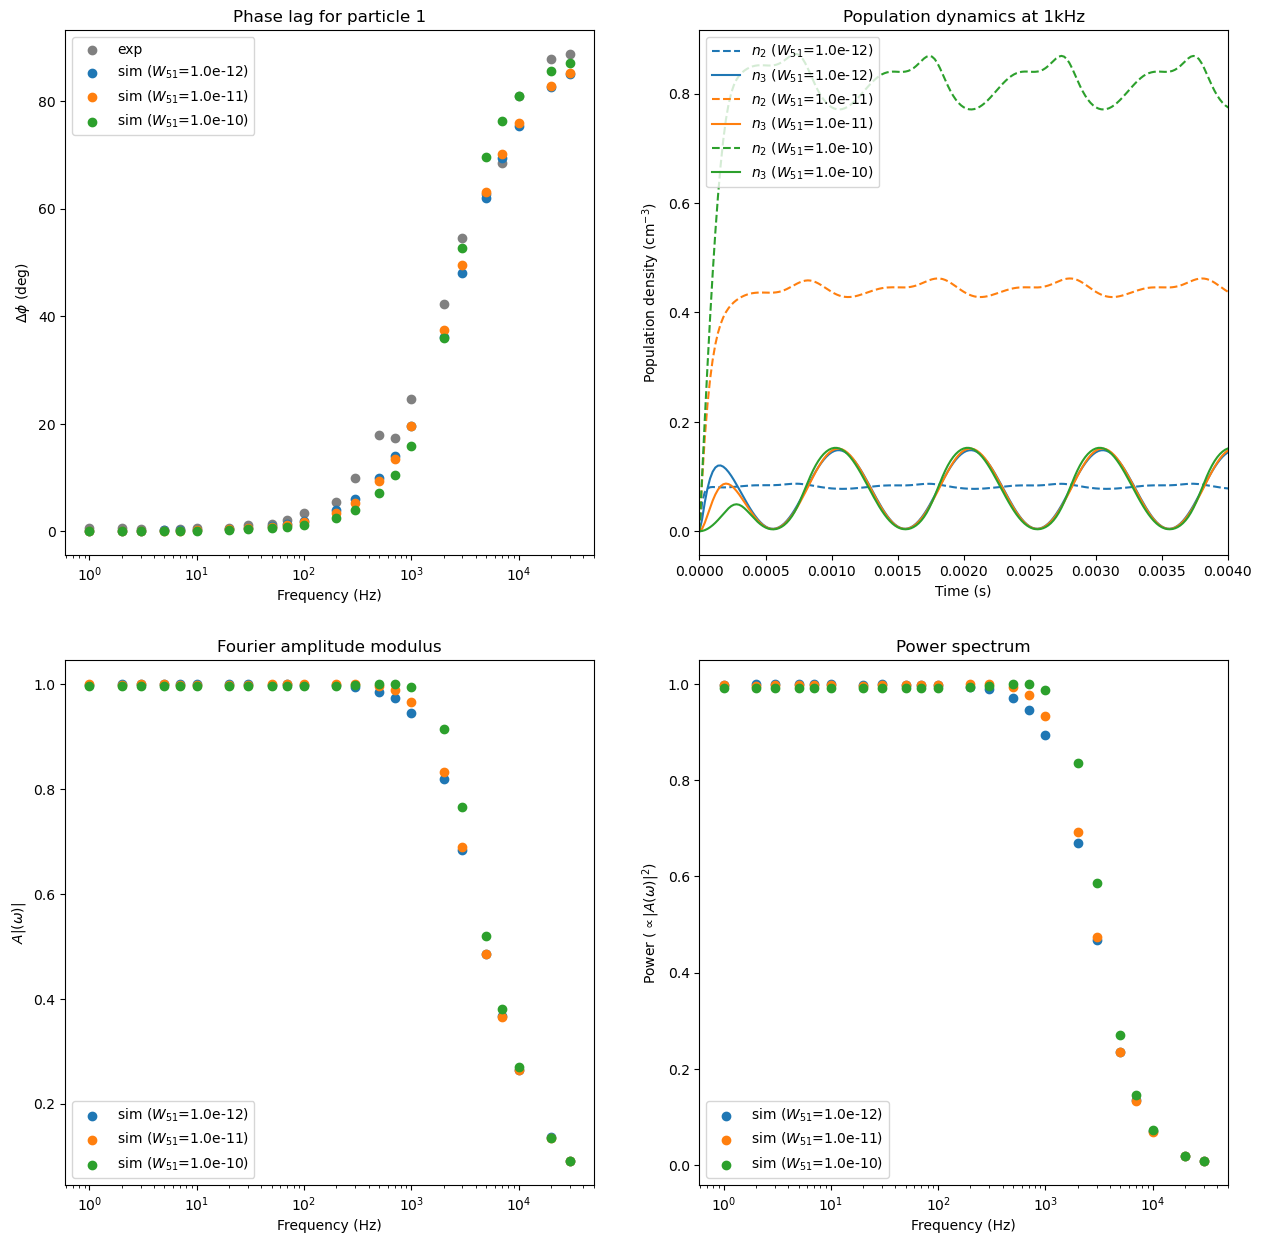

In [23]:
k21 = 16.66
k31 = 17237.7
k54 = 1279.0
sigma = 1.75e-20
ww51 = 1.0e-11
ww52 = 1.0e-11

params_w51 = [[ww51*10**(i-1), ww52, k21, k31, k54] for i in range(3)]

# Define system
def odes(t, x, W51, W52, ks, freq):
    k21, k31, k54 = ks
    #Define new rates
    kpp21 = lambda f, k21: k21/f
    kpp31 = lambda f, k31: k31/f
    kpp54 = lambda f, k54: k54/f

    # The 't' here represents the dimensionless variable tau (tau = t*f)
    x1, x2, x3, x4, x5 = x

    # Laser function according to previously defined settings
    F_t = offset + amplitude * np.cos(2 * np.pi * t)

    # Numerical safeguard: intensity cannot be negative.
    if F_t < 0: F_t = 0.0 

    # Yb3+ populations    
    dx5_dt = (kp45(freq) * F_t * x4 - wp51(freq, W51) * x5 * x1 
              - wp52(freq, W52) * x5 * x2 - kpp54(freq, k54) * x5)
    dx4_dt = -dx5_dt

    # Er3+ populations
    dx3_dt = wp52(freq, W52) * x5 * x2 - kpp31(freq, k31) * x3
    dx2_dt = wp51(freq, W51) * x5 * x1 - wp52(freq, W52) * x5 * x2 - kpp21(freq, k21) * x2 
    dx1_dt = -(dx3_dt + dx2_dt) 
    
    return [dx1_dt, dx2_dt, dx3_dt, dx4_dt, dx5_dt]


# ---> CRIAÇÃO DA FIGURA MOVIDA PARA FORA DO LOOP <---
fig, axs = plt.subplots(2, 2, figsize=(15, 15))

for idx, param in enumerate(params_w51):
    # if iv_idx !=0: continue
    
    ww51, ww52, k21, k31, k54 = param

    print(f"k21 = {k21}")
    print(f"k31 = {k31}")
    print(f"k54 = {k54}")
    print(f"w51 = {ww51}")
    print(f"w52 = {ww52}")

    fases_calculadas = []

    for p_id, pd in enumerate(pd_list):
        if p_id != 0: continue
        frequencias_experimentais = pd[:num_points, 0] 
        fases_experimentais = pd[:num_points, 1] 

        W51, W52 = ww51, ww52

        sol_to_plot = []

        amps_list = []
        for f in frequencias_experimentais:
            # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
            t_span = (0, 200) 
            t_eval = np.linspace(t_span[0], t_span[1], 10000)

            sol = solve_ivp(
            odes, 
            t_span, 
            [n1_0/n0, 0, 0, n4_0/n0, 0], #x1 x2 x3 x4 x5 @ t=0
            t_eval=t_eval,
            args=(W51, W52, [k21, k31, k54], f), 
            method='Radau' # Mantendo o método Radau que demonstrou estabilidade acima
            )

            # Converte de volta para unidades físicas antes de extrair a fase
            n3 = (sol.y[2]) * n0 
            ts = (sol.t) * (1/f)

            n2 = (sol.y[1]) * n0 
            n11 = (sol.y[0]) * n0 

            if f == 1000:
                sol_to_plot = [ts, n11, n2, n3]

            fase_calc = extrair_fase(ts, n3, f)
            fases_calculadas.append(fase_calc)
            amps_list.append(get_fft_amp(ts, n3, f))

        fases_calculadas = np.unwrap(np.array(fases_calculadas))
        amps_list = np.array(amps_list)
        powers = amps_list**2

        # ---> PLOTS ATUALIZADOS PARA ADICIONAR NA MESMA FIGURA <---
        
        # Phase lag plot
        if idx == 0: # Plota o experimental apenas 1 vez
            axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_experimentais), color="gray", label="exp")
            
        axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_calculadas), label=f"sim ($W_{{51}}$={W51:.1e})")
        axs[0,0].set_xscale("log")
        axs[0,0].set_ylabel("$\Delta \phi$ (deg)")
        axs[0,0].set_xlabel("Frequency (Hz)")
        axs[0,0].set_title("Phase lag for particle 1")
        
        # Population time evolution @ 1kHz
        ts, n11, n2, n3 = sol_to_plot
        
        # Nota: As cores das populações agora variam, ou você pode diferenciar n2 e n3 por estilo de linha
        linha, = axs[0,1].plot(ts, n2/n11.max(), linestyle="--",label=f"$n_2$ ($W_{{51}}$={W51:.1e})")
        axs[0,1].plot(ts, n3/n11.max(), color=linha.get_color(), label=f"$n_3$ ($W_{{51}}$={W51:.1e})")
        
        axs[0,1].set_ylabel("Population density (cm$^{-3}$)")
        axs[0,1].set_xlabel("Time (s)")
        axs[0,1].set_xlim([0,ts[int(len(ts)*(0.02))]])
        axs[0,1].set_title("Population dynamics at 1kHz")

        # Amplitudes plot
        axs[1,0].scatter(frequencias_experimentais, amps_list/amps_list.max(), label=f"sim ($W_{{51}}$={W51:.1e})")
        axs[1,0].set_ylabel("$A|(\omega)|$")
        axs[1,0].set_xlabel("Frequency (Hz)")
        axs[1,0].set_xscale("log")
        axs[1,0].set_title("Fourier amplitude modulus")

        # Power plot
        axs[1,1].scatter(frequencias_experimentais, powers/(powers).max(), label=f"sim ($W_{{51}}$={W51:.1e})")
        axs[1,1].set_ylabel("Power ($\propto |A(\omega)|^2$)")
        axs[1,1].set_xlabel("Frequency (Hz)")
        axs[1,1].set_xscale("log")
        axs[1,1].set_title("Power spectrum")


# ---> LEGENDAS MOVIDAS PARA FORA DO LOOP PARA CAPTURAR TODAS AS CURVAS <---
axs[0,0].legend()
axs[0,1].legend()
axs[1,0].legend()
axs[1,1].legend()

plt.show()

k21 = 16.66
k31 = 17237.7
k54 = 1279.0
w51 = 1e-12
w52 = 1e-11
k21 = 16.66
k31 = 17237.7
k54 = 1279.0
w51 = 1e-11
w52 = 1e-11
k21 = 16.66
k31 = 17237.7
k54 = 1279.0
w51 = 9.999999999999999e-11
w52 = 1e-11


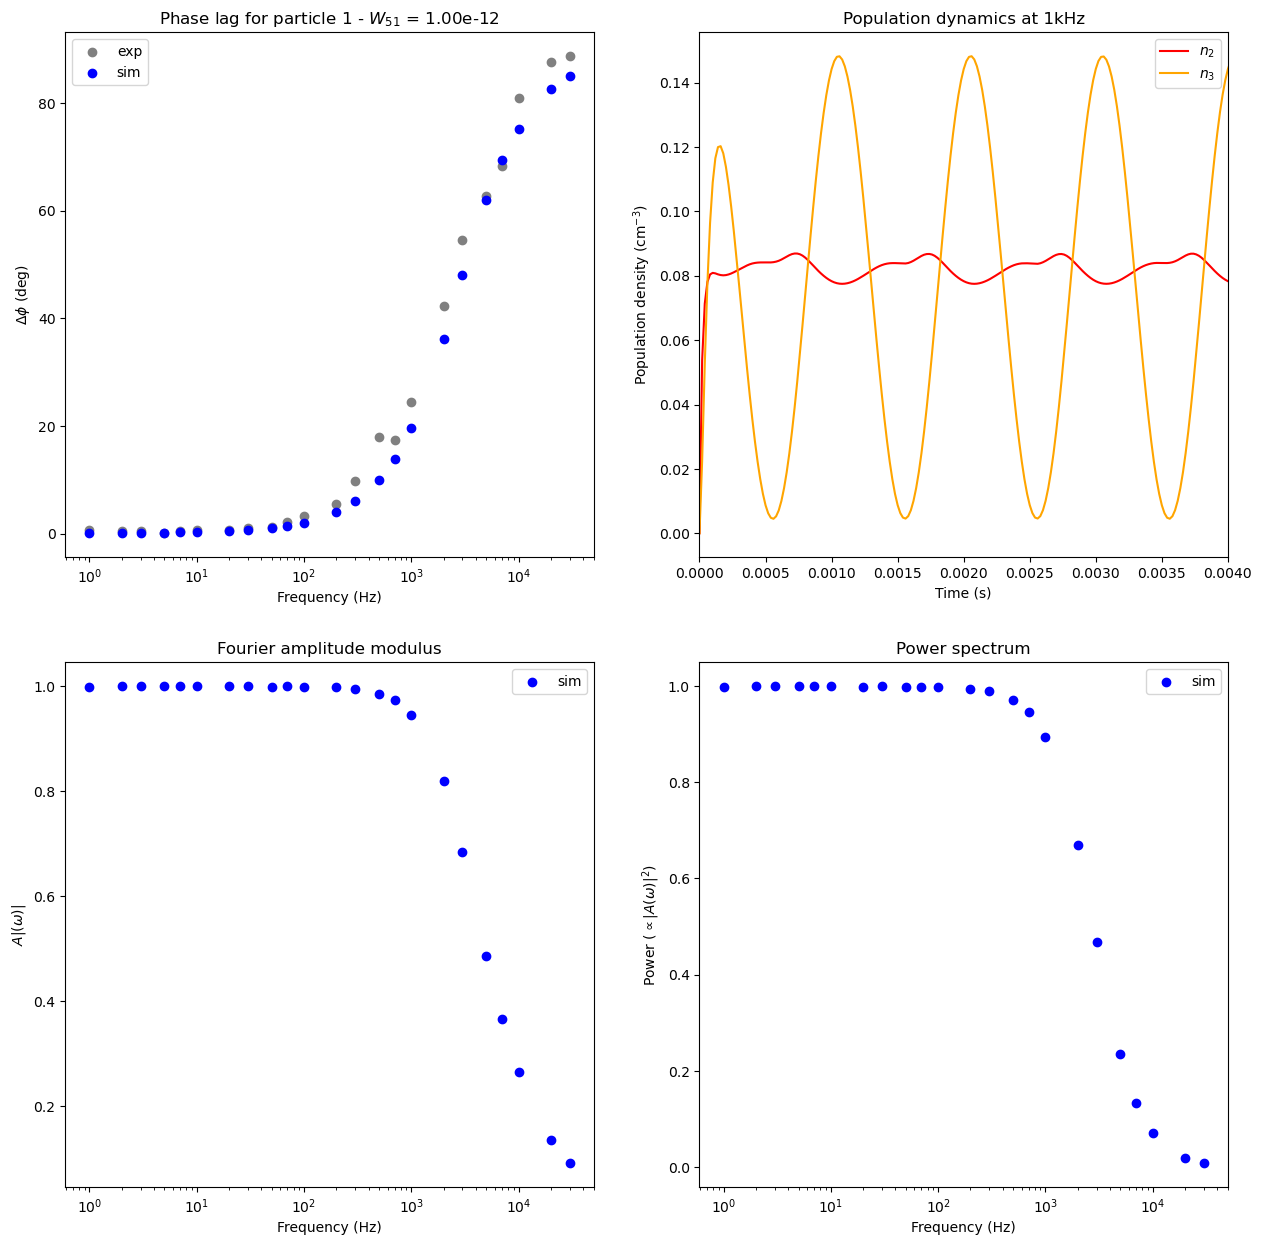

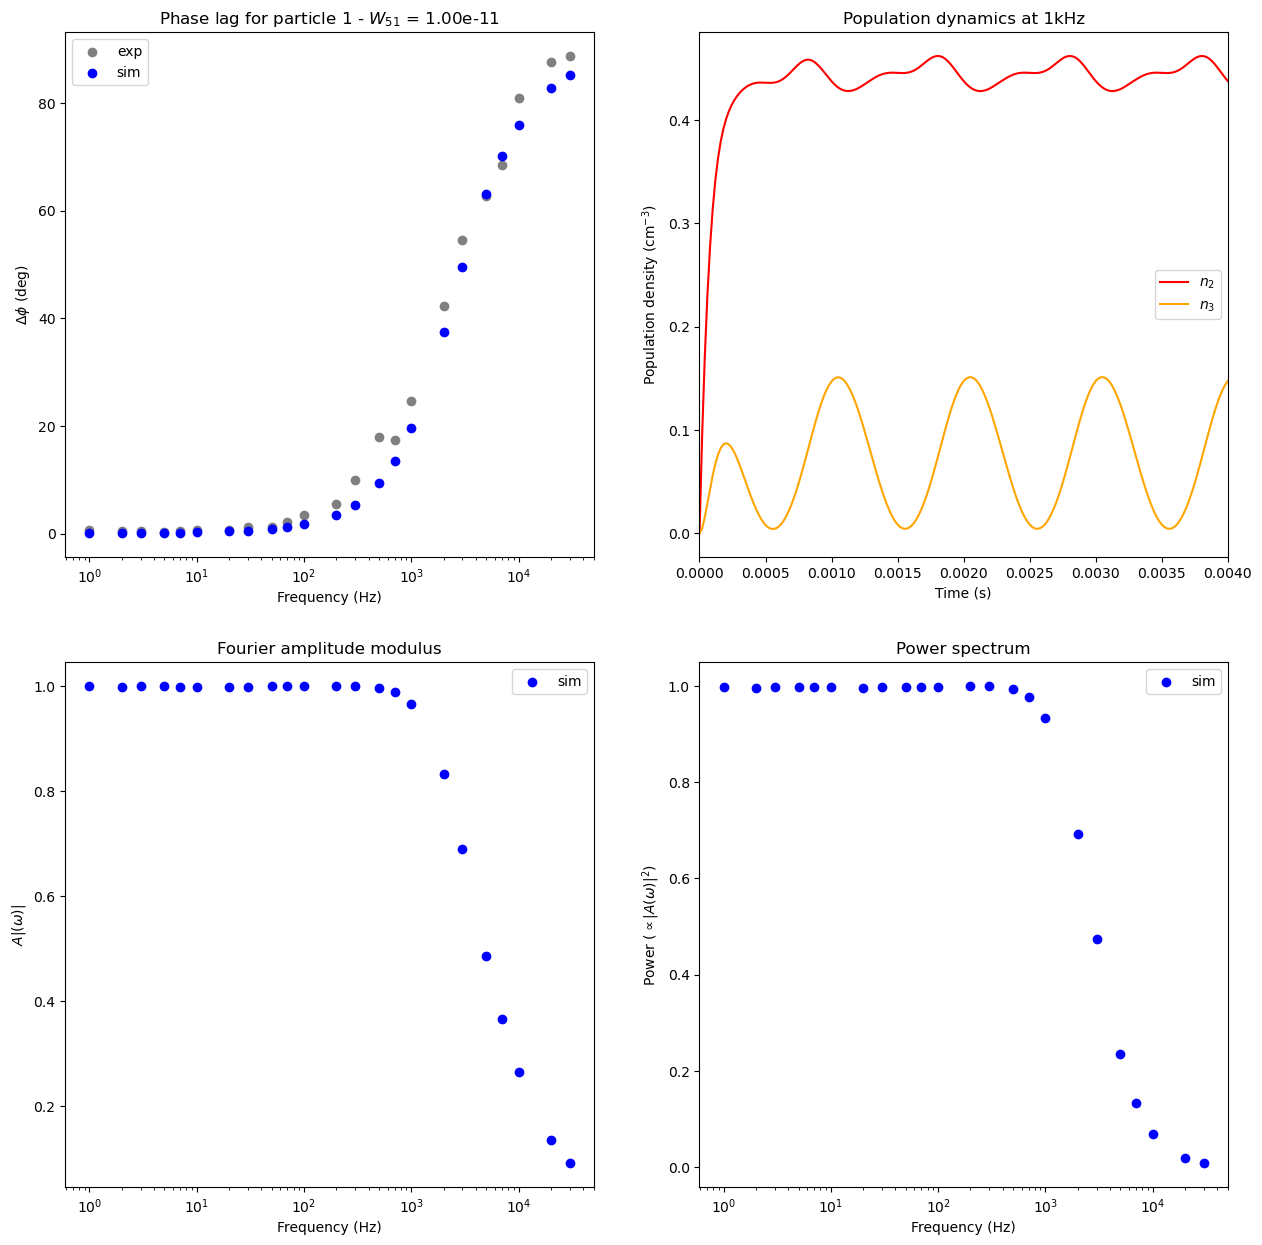

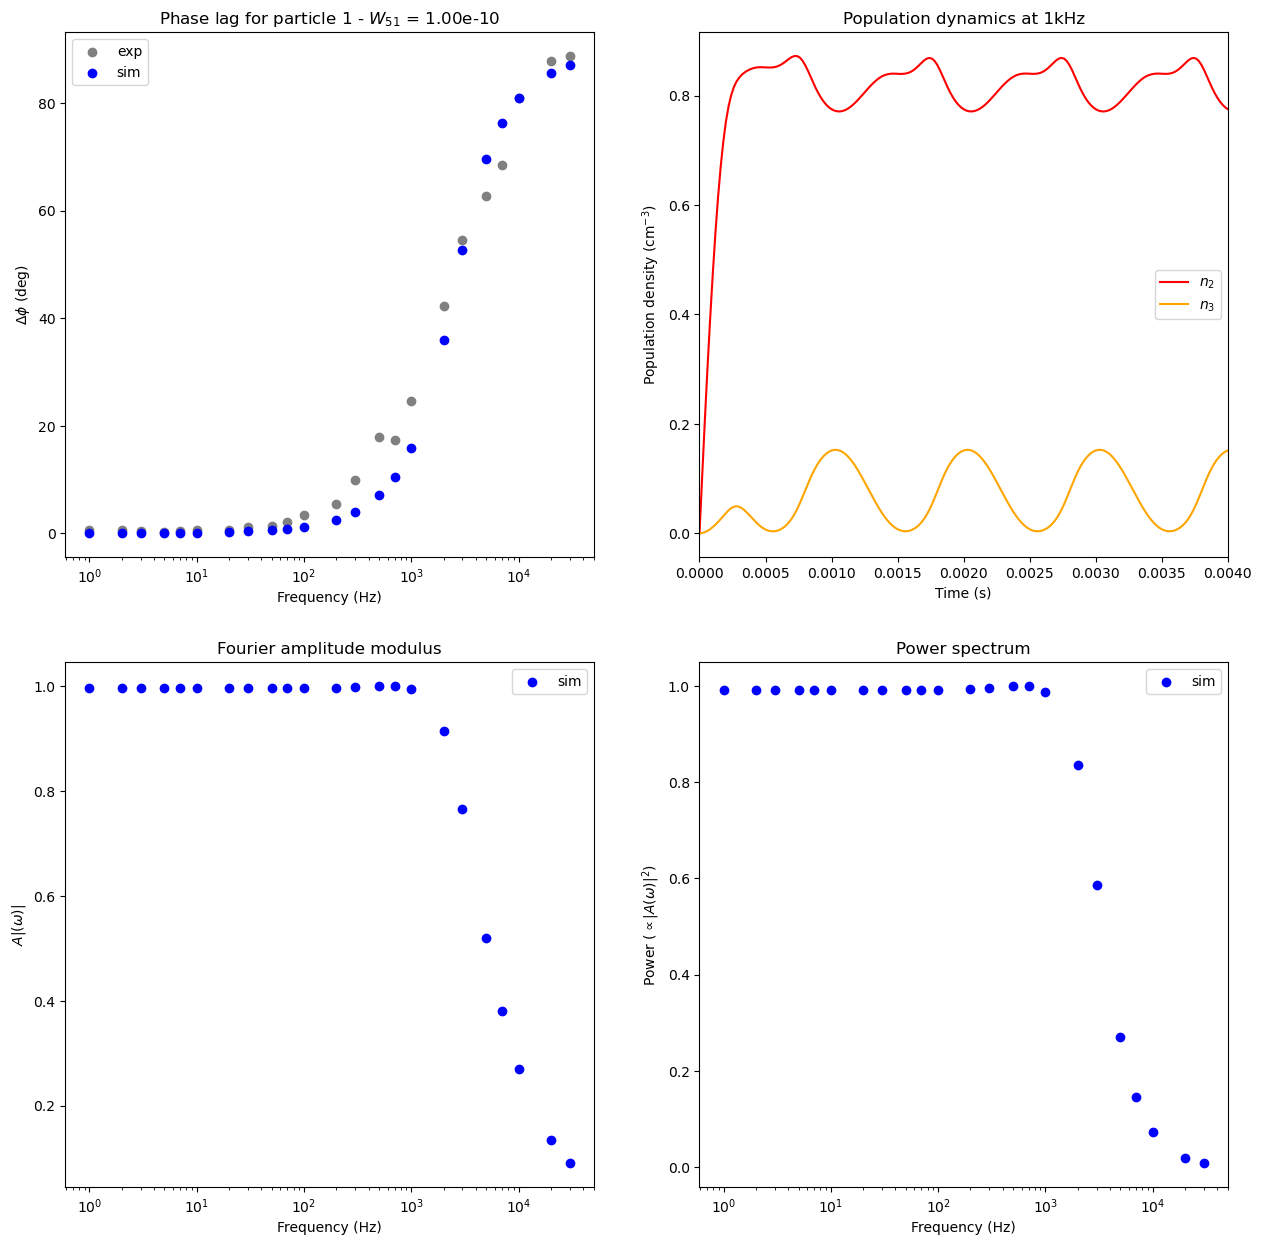

In [11]:
k21 = 16.66
k31 = 17237.7
k54 = 1279.0
sigma = 1.75e-20
ww51 = 1.0e-11
ww52 = 1.0e-11

params_w51 = [[ww51*10**(i-1), ww52, k21, k31, k54] for i in range(3)]

# Define system
def odes(t, x, W51, W52, ks, freq):
    k21, k31, k54 = ks
    #Define new rates
    kpp21 = lambda f, k21: k21/f
    kpp31 = lambda f, k31: k31/f
    kpp54 = lambda f, k54: k54/f


    # The 't' here represents the dimensionless variable tau (tau = t*f)
    x1, x2, x3, x4, x5 = x

    # Laser function according to previously defined settings
    F_t = offset + amplitude * np.cos(2 * np.pi * t)

    # Numerical safeguard: intensity cannot be negative.
    if F_t < 0: F_t = 0.0 

    # Yb3+ populations    
    dx5_dt = (kp45(freq) * F_t * x4 - wp51(freq, W51) * x5 * x1 
              - wp52(freq, W52) * x5 * x2 - kpp54(freq, k54) * x5)
    dx4_dt = -dx5_dt

    # Er3+ populations
    dx3_dt = wp52(freq, W52) * x5 * x2 - kpp31(freq, k31) * x3
    dx2_dt = wp51(freq, W51) * x5 * x1 - wp52(freq, W52) * x5 * x2 - kpp21(freq, k21) * x2 
    dx1_dt = -(dx3_dt + dx2_dt) 
    
    return [dx1_dt, dx2_dt, dx3_dt, dx4_dt, dx5_dt]



for idx, param in enumerate(params_w51):
    # if iv_idx !=0: continue
    
    ww51, ww52, k21, k31, k54 = param

    print(f"k21 = {k21}")
    print(f"k31 = {k31}")
    print(f"k54 = {k54}")
    print(f"w51 = {ww51}")
    print(f"w52 = {ww52}")

    fases_calculadas = []

    for p_id, pd in enumerate(pd_list):
        if p_id != 0: continue
        frequencias_experimentais = pd[:num_points, 0] 
        fases_experimentais = pd[:num_points, 1] 

        W51, W52 = ww51, ww52

        sol_to_plot = []

        amps_list = []
        for f in frequencias_experimentais:
            # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
            t_span = (0, 200) 
            t_eval = np.linspace(t_span[0], t_span[1], 10000)

            sol = solve_ivp(
            odes, 
            t_span, 
            [n1_0/n0, 0, 0, n4_0/n0, 0], #x1 x2 x3 x4 x5 @ t=0
            t_eval=t_eval,
            args=(W51, W52, [k21, k31, k54], f), 
            method='Radau' # Mantendo o método Radau que demonstrou estabilidade acima
            )


            # Converte de volta para unidades físicas antes de extrair a fase
            n3 = (sol.y[2]) * n0 
            ts = (sol.t) * (1/f)

            n2 = (sol.y[1]) * n0 
            n11 = (sol.y[0]) * n0 

            if f == 1000:
                sol_to_plot = [ts, n11, n2, n3]

            # plt.plt(ts, n11)

            fase_calc = extrair_fase(ts, n3, f)
            fases_calculadas.append(fase_calc)
            amps_list.append(get_fft_amp(ts, n3, f))

        fases_calculadas = np.unwrap(np.array(fases_calculadas))
        amps_list = np.array(amps_list)
        powers = amps_list**2

        fig, axs = plt.subplots(2, 2, figsize=(15, 15))

        #Phase lag plot
        axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_experimentais), color="gray", label="exp")
        axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_calculadas), color="blue", label="sim")
        axs[0,0].set_xscale("log")
        axs[0,0].set_ylabel("$\Delta \phi$ (deg)")
        axs[0,0].set_xlabel("Frequency (Hz)")
        axs[0,0].set_title("Phase lag for particle 1 - $W_{51}$ = "+f"{W51:.2e}")
        axs[0,0].legend()
        
        #Population time evolution @ 1kHz
        ts, n11, n2, n3 = sol_to_plot
        # axs[1].plot(ts, n11/n11.max(), color="lightblue", label="$n_1$(t)")
        axs[0,1].plot(ts, n2/n11.max(), color="red", label="$n_2$")
        axs[0,1].plot(ts, n3/n11.max(), color="orange", label="$n_3$")
        # axs[0,1].set_xscale("log")
        axs[0,1].set_ylabel("Population density (cm$^{-3}$)")
        axs[0,1].set_xlabel("Time (s)")
        axs[0,1].set_xlim([0,ts[int(len(ts)*(0.02))]])
        axs[0,1].set_title(f"Population dynamics at 1kHz")
        axs[0,1].legend()

        
        #Amplitudes plot
        axs[1,0].scatter(frequencias_experimentais, amps_list/amps_list.max(), color="blue", label="sim")
        axs[1,0].set_ylabel("$A|(\omega)|$")
        axs[1,0].set_xlabel("Frequency (Hz)")
        axs[1,0].set_xscale("log")
        axs[1,0].set_title(f"Fourier amplitude modulus")
        axs[1,0].legend()

        #Power plot
        axs[1,1].scatter(frequencias_experimentais, powers/(powers).max(), color="blue", label="sim")
        axs[1,1].set_ylabel("Power ($\propto |A(\omega)|^2$)")
        axs[1,1].set_xlabel("Frequency (Hz)")
        axs[1,1].set_xscale("log")
        axs[1,1].set_title("Power spectrum")
        axs[1,1].legend()


plt.show()

#### Variando $W_{52}$

k21 = 16.66
k31 = 17237.7
k54 = 1279.0
w51 = 1e-11
w52 = 1e-12
k21 = 16.66
k31 = 17237.7
k54 = 1279.0
w51 = 1e-11
w52 = 1e-11
k21 = 16.66
k31 = 17237.7
k54 = 1279.0
w51 = 1e-11
w52 = 9.999999999999999e-11


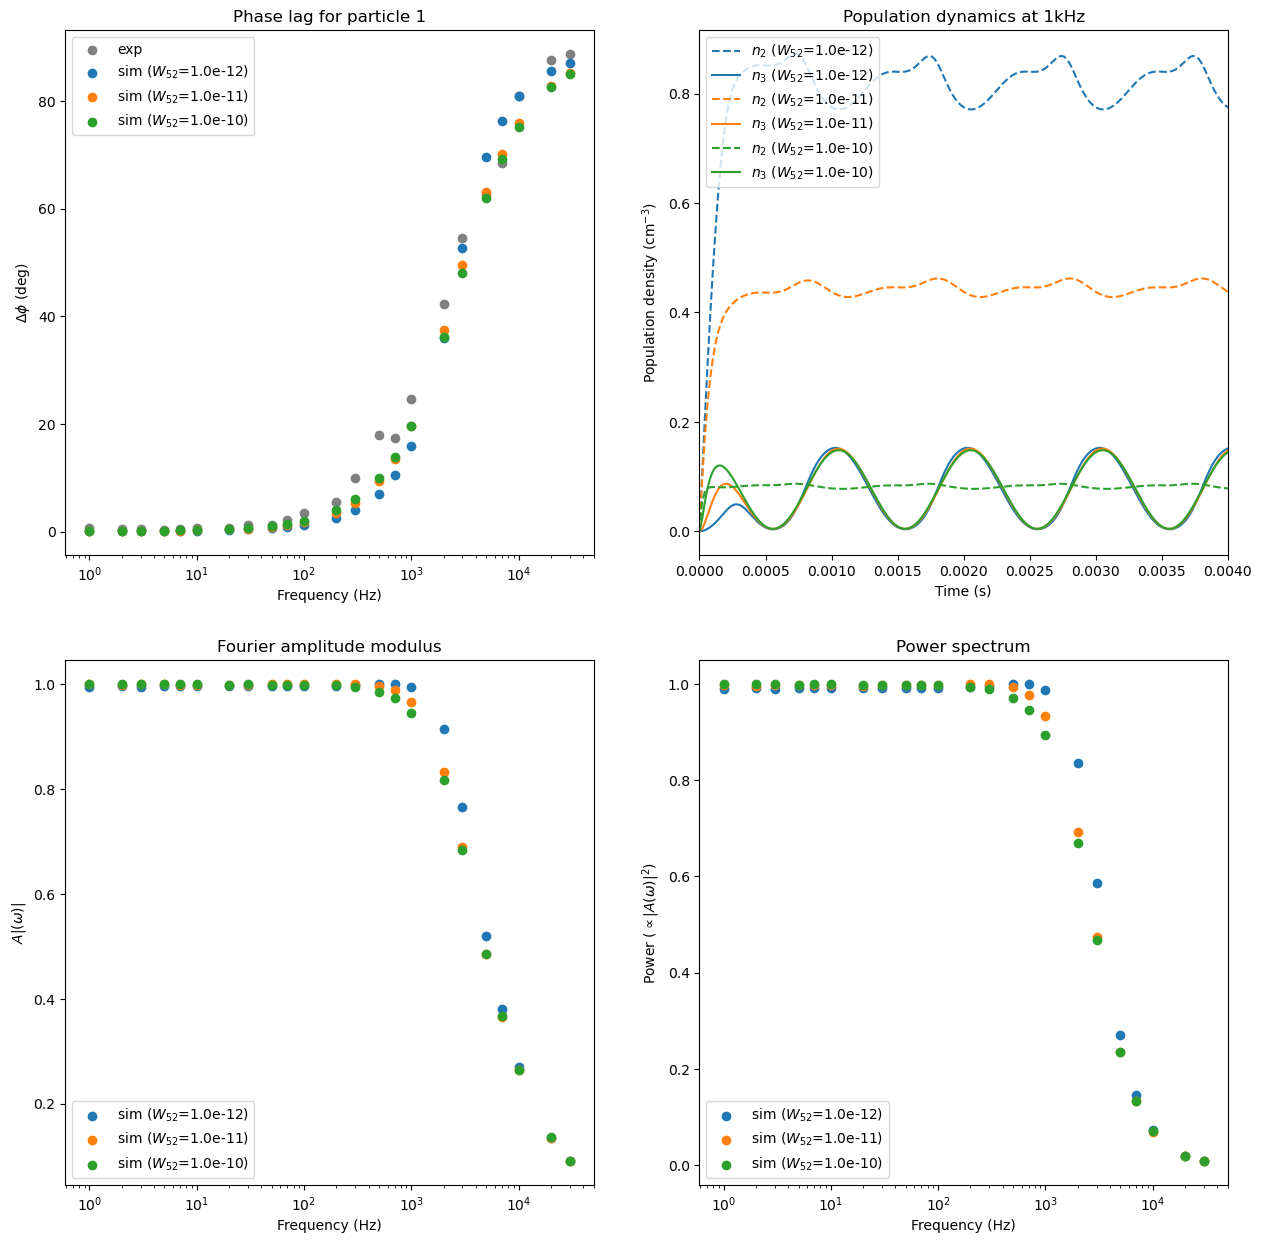

In [24]:
k21 = 16.66
k31 = 17237.7
k54 = 1279.0
sigma = 1.75e-20
ww51 = 1.0e-11
ww52 = 1.0e-11

params_w52 = [[ww51, ww52*10**(i-1), k21, k31, k54] for i in range(3)]


# Define system
def odes(t, x, W51, W52, ks, freq):
    k21, k31, k54 = ks
    #Define new rates
    kpp21 = lambda f, k21: k21/f
    kpp31 = lambda f, k31: k31/f
    kpp54 = lambda f, k54: k54/f

    # The 't' here represents the dimensionless variable tau (tau = t*f)
    x1, x2, x3, x4, x5 = x

    # Laser function according to previously defined settings
    F_t = offset + amplitude * np.cos(2 * np.pi * t)

    # Numerical safeguard: intensity cannot be negative.
    if F_t < 0: F_t = 0.0 

    # Yb3+ populations    
    dx5_dt = (kp45(freq) * F_t * x4 - wp51(freq, W51) * x5 * x1 
              - wp52(freq, W52) * x5 * x2 - kpp54(freq, k54) * x5)
    dx4_dt = -dx5_dt

    # Er3+ populations
    dx3_dt = wp52(freq, W52) * x5 * x2 - kpp31(freq, k31) * x3
    dx2_dt = wp51(freq, W51) * x5 * x1 - wp52(freq, W52) * x5 * x2 - kpp21(freq, k21) * x2 
    dx1_dt = -(dx3_dt + dx2_dt) 
    
    return [dx1_dt, dx2_dt, dx3_dt, dx4_dt, dx5_dt]


# ---> CRIAÇÃO DA FIGURA MOVIDA PARA FORA DO LOOP <---
fig, axs = plt.subplots(2, 2, figsize=(15, 15))

for idx, param in enumerate(params_w52):
    # if iv_idx !=0: continue
    
    ww51, ww52, k21, k31, k54 = param

    print(f"k21 = {k21}")
    print(f"k31 = {k31}")
    print(f"k54 = {k54}")
    print(f"w51 = {ww51}")
    print(f"w52 = {ww52}")

    fases_calculadas = []

    for p_id, pd in enumerate(pd_list):
        if p_id != 0: continue
        frequencias_experimentais = pd[:num_points, 0] 
        fases_experimentais = pd[:num_points, 1] 

        W51, W52 = ww51, ww52

        sol_to_plot = []

        amps_list = []
        for f in frequencias_experimentais:
            # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
            t_span = (0, 200) 
            t_eval = np.linspace(t_span[0], t_span[1], 10000)

            sol = solve_ivp(
            odes, 
            t_span, 
            [n1_0/n0, 0, 0, n4_0/n0, 0], #x1 x2 x3 x4 x5 @ t=0
            t_eval=t_eval,
            args=(W51, W52, [k21, k31, k54], f), 
            method='Radau' # Mantendo o método Radau que demonstrou estabilidade acima
            )

            # Converte de volta para unidades físicas antes de extrair a fase
            n3 = (sol.y[2]) * n0 
            ts = (sol.t) * (1/f)

            n2 = (sol.y[1]) * n0 
            n11 = (sol.y[0]) * n0 

            if f == 1000:
                sol_to_plot = [ts, n11, n2, n3]

            fase_calc = extrair_fase(ts, n3, f)
            fases_calculadas.append(fase_calc)
            amps_list.append(get_fft_amp(ts, n3, f))

        fases_calculadas = np.unwrap(np.array(fases_calculadas))
        amps_list = np.array(amps_list)
        powers = amps_list**2

        # ---> PLOTS ATUALIZADOS PARA ADICIONAR NA MESMA FIGURA <---
        
        # Phase lag plot
        if idx == 0: # Plota o experimental apenas 1 vez
            axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_experimentais), color="gray", label="exp")
            
        axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_calculadas), label=f"sim ($W_{{52}}$={W52:.1e})")
        axs[0,0].set_xscale("log")
        axs[0,0].set_ylabel("$\Delta \phi$ (deg)")
        axs[0,0].set_xlabel("Frequency (Hz)")
        axs[0,0].set_title("Phase lag for particle 1")
        
        # Population time evolution @ 1kHz
        ts, n11, n2, n3 = sol_to_plot
        
        # Nota: As cores das populações agora variam, ou você pode diferenciar n2 e n3 por estilo de linha
        linha, = axs[0,1].plot(ts, n2/n11.max(), linestyle="--",label=f"$n_2$ ($W_{{52}}$={W52:.1e})")
        axs[0,1].plot(ts, n3/n11.max(), color=linha.get_color(), label=f"$n_3$ ($W_{{52}}$={W52:.1e})")
        
        axs[0,1].set_ylabel("Population density (cm$^{-3}$)")
        axs[0,1].set_xlabel("Time (s)")
        axs[0,1].set_xlim([0,ts[int(len(ts)*(0.02))]])
        axs[0,1].set_title("Population dynamics at 1kHz")

        # Amplitudes plot
        axs[1,0].scatter(frequencias_experimentais, amps_list/amps_list.max(), label=f"sim ($W_{{52}}$={W52:.1e})")
        axs[1,0].set_ylabel("$A|(\omega)|$")
        axs[1,0].set_xlabel("Frequency (Hz)")
        axs[1,0].set_xscale("log")
        axs[1,0].set_title("Fourier amplitude modulus")

        # Power plot
        axs[1,1].scatter(frequencias_experimentais, powers/(powers).max(), label=f"sim ($W_{{52}}$={W52:.1e})")
        axs[1,1].set_ylabel("Power ($\propto |A(\omega)|^2$)")
        axs[1,1].set_xlabel("Frequency (Hz)")
        axs[1,1].set_xscale("log")
        axs[1,1].set_title("Power spectrum")


# ---> LEGENDAS MOVIDAS PARA FORA DO LOOP PARA CAPTURAR TODAS AS CURVAS <---
axs[0,0].legend()
axs[0,1].legend()
axs[1,0].legend()
axs[1,1].legend()

plt.show()

#### Variando $k_{21}$

k21 = 8.33
k31 = 17237.7
k54 = 1279.0
w51 = 1e-11
w52 = 1e-11
k21 = 16.66
k31 = 17237.7
k54 = 1279.0
w51 = 1e-11
w52 = 1e-11
k21 = 24.990000000000002
k31 = 17237.7
k54 = 1279.0
w51 = 1e-11
w52 = 1e-11


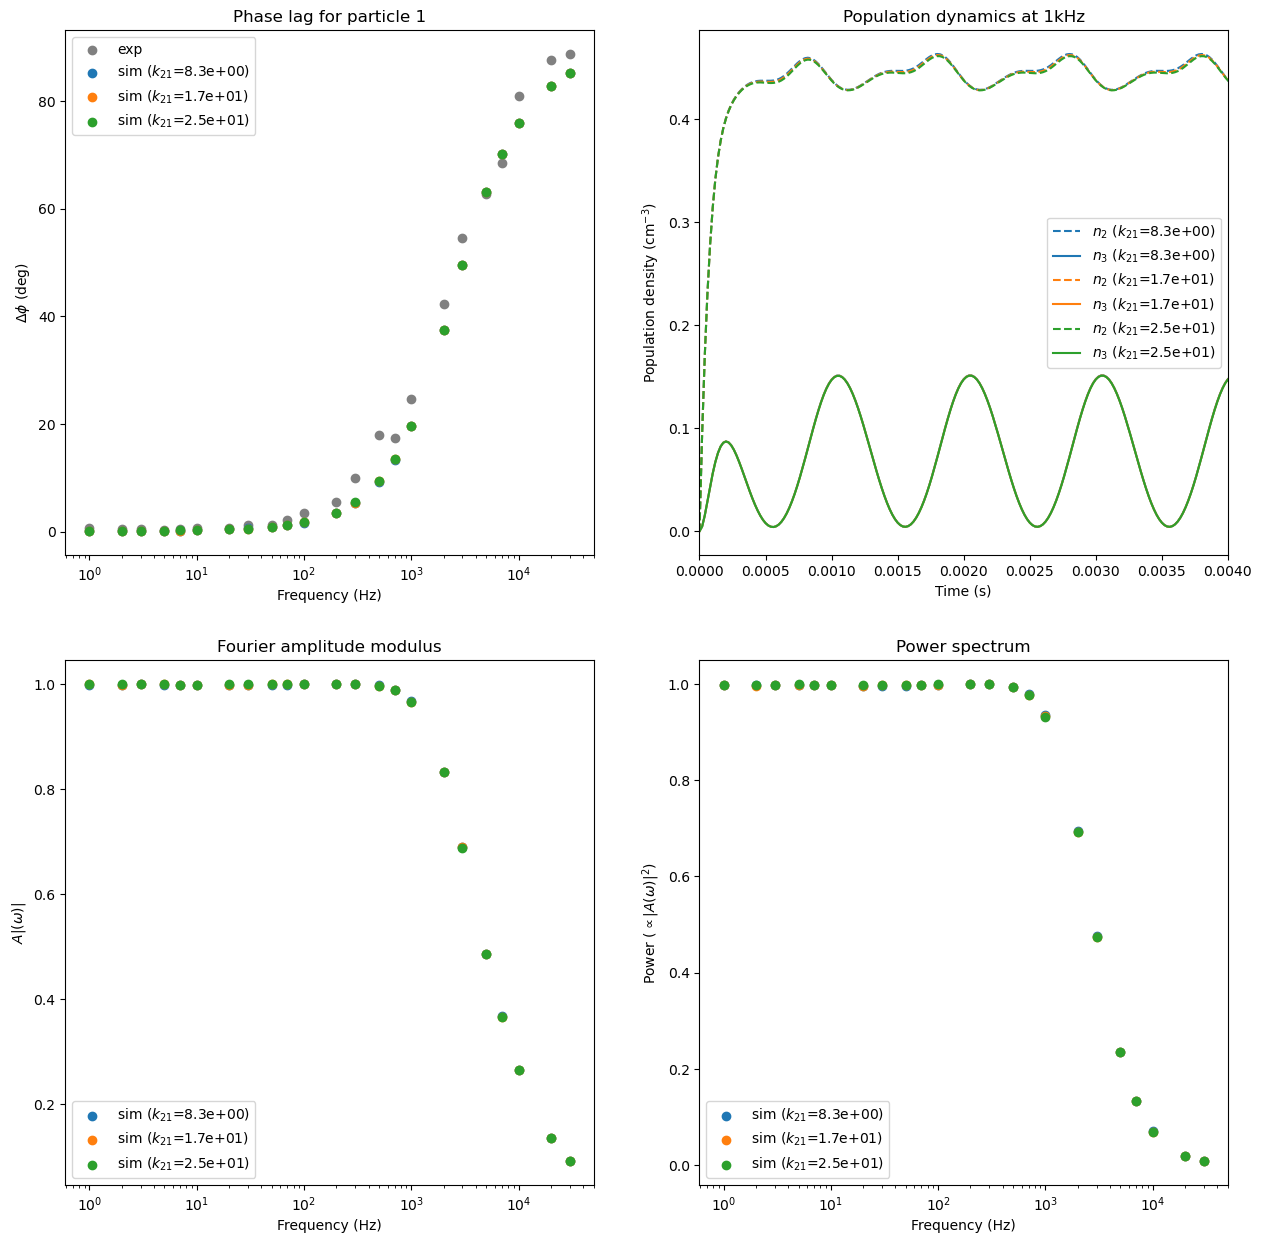

In [25]:
k21 = 16.66
k31 = 17237.7
k54 = 1279.0
sigma = 1.75e-20
ww51 = 1.0e-11
ww52 = 1.0e-11

params_k21 = [[ww51, ww52, k21*(i+1)/2, k31, k54] for i in range(3)] #Varia de 0.5, 1.0, 1.5

# Define system
def odes(t, x, W51, W52, ks, freq):
    k21, k31, k54 = ks
    #Define new rates
    kpp21 = lambda f, k21: k21/f
    kpp31 = lambda f, k31: k31/f
    kpp54 = lambda f, k54: k54/f

    # The 't' here represents the dimensionless variable tau (tau = t*f)
    x1, x2, x3, x4, x5 = x

    # Laser function according to previously defined settings
    F_t = offset + amplitude * np.cos(2 * np.pi * t)

    # Numerical safeguard: intensity cannot be negative.
    if F_t < 0: F_t = 0.0 

    # Yb3+ populations    
    dx5_dt = (kp45(freq) * F_t * x4 - wp51(freq, W51) * x5 * x1 
              - wp52(freq, W52) * x5 * x2 - kpp54(freq, k54) * x5)
    dx4_dt = -dx5_dt

    # Er3+ populations
    dx3_dt = wp52(freq, W52) * x5 * x2 - kpp31(freq, k31) * x3
    dx2_dt = wp51(freq, W51) * x5 * x1 - wp52(freq, W52) * x5 * x2 - kpp21(freq, k21) * x2 
    dx1_dt = -(dx3_dt + dx2_dt) 
    
    return [dx1_dt, dx2_dt, dx3_dt, dx4_dt, dx5_dt]


# ---> CRIAÇÃO DA FIGURA MOVIDA PARA FORA DO LOOP <---
fig, axs = plt.subplots(2, 2, figsize=(15, 15))

for idx, param in enumerate(params_k21):
    # if iv_idx !=0: continue
    
    ww51, ww52, k21, k31, k54 = param

    print(f"k21 = {k21}")
    print(f"k31 = {k31}")
    print(f"k54 = {k54}")
    print(f"w51 = {ww51}")
    print(f"w52 = {ww52}")

    fases_calculadas = []

    for p_id, pd in enumerate(pd_list):
        if p_id != 0: continue
        frequencias_experimentais = pd[:num_points, 0] 
        fases_experimentais = pd[:num_points, 1] 

        W51, W52 = ww51, ww52

        sol_to_plot = []

        amps_list = []
        for f in frequencias_experimentais:
            # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
            t_span = (0, 200) 
            t_eval = np.linspace(t_span[0], t_span[1], 10000)

            sol = solve_ivp(
            odes, 
            t_span, 
            [n1_0/n0, 0, 0, n4_0/n0, 0], #x1 x2 x3 x4 x5 @ t=0
            t_eval=t_eval,
            args=(W51, W52, [k21, k31, k54], f), 
            method='Radau' # Mantendo o método Radau que demonstrou estabilidade acima
            )

            # Converte de volta para unidades físicas antes de extrair a fase
            n3 = (sol.y[2]) * n0 
            ts = (sol.t) * (1/f)

            n2 = (sol.y[1]) * n0 
            n11 = (sol.y[0]) * n0 

            if f == 1000:
                sol_to_plot = [ts, n11, n2, n3]

            fase_calc = extrair_fase(ts, n3, f)
            fases_calculadas.append(fase_calc)
            amps_list.append(get_fft_amp(ts, n3, f))

        fases_calculadas = np.unwrap(np.array(fases_calculadas))
        amps_list = np.array(amps_list)
        powers = amps_list**2

        # ---> PLOTS ATUALIZADOS PARA ADICIONAR NA MESMA FIGURA <---
        
        # Phase lag plot
        if idx == 0: # Plota o experimental apenas 1 vez
            axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_experimentais), color="gray", label="exp")
            
        axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_calculadas), label=f"sim ($k_{{21}}$={k21:.1e})")
        axs[0,0].set_xscale("log")
        axs[0,0].set_ylabel("$\Delta \phi$ (deg)")
        axs[0,0].set_xlabel("Frequency (Hz)")
        axs[0,0].set_title("Phase lag for particle 1")
        
        # Population time evolution @ 1kHz
        ts, n11, n2, n3 = sol_to_plot
        
        # Nota: As cores das populações agora variam, ou você pode diferenciar n2 e n3 por estilo de linha
        linha, = axs[0,1].plot(ts, n2/n11.max(), linestyle="--",label=f"$n_2$ ($k_{{21}}$={k21:.1e})")
        axs[0,1].plot(ts, n3/n11.max(), color=linha.get_color(), label=f"$n_3$ ($k_{{21}}$={k21:.1e})")
        
        axs[0,1].set_ylabel("Population density (cm$^{-3}$)")
        axs[0,1].set_xlabel("Time (s)")
        axs[0,1].set_xlim([0,ts[int(len(ts)*(0.02))]])
        axs[0,1].set_title("Population dynamics at 1kHz")

        # Amplitudes plot
        axs[1,0].scatter(frequencias_experimentais, amps_list/amps_list.max(), label=f"sim ($k_{{21}}$={k21:.1e})")
        axs[1,0].set_ylabel("$A|(\omega)|$")
        axs[1,0].set_xlabel("Frequency (Hz)")
        axs[1,0].set_xscale("log")
        axs[1,0].set_title("Fourier amplitude modulus")

        # Power plot
        axs[1,1].scatter(frequencias_experimentais, powers/(powers).max(), label=f"sim ($k_{{21}}$={k21:.1e})")
        axs[1,1].set_ylabel("Power ($\propto |A(\omega)|^2$)")
        axs[1,1].set_xlabel("Frequency (Hz)")
        axs[1,1].set_xscale("log")
        axs[1,1].set_title("Power spectrum")


# ---> LEGENDAS MOVIDAS PARA FORA DO LOOP PARA CAPTURAR TODAS AS CURVAS <---
axs[0,0].legend()
axs[0,1].legend()
axs[1,0].legend()
axs[1,1].legend()

plt.show()

#### Variando $k_{31}$

In [ ]:
k21 = 16.66
k31 = 17237.7
k54 = 1279.0
sigma = 1.75e-20
ww51 = 1.0e-11
ww52 = 1.0e-11

params_k21 = [[ww51, ww52, k21, k31*(i+1)/2, k54] for i in range(3)] #Varia de 0.5, 1.0, 1.5

# Define system
def odes(t, x, W51, W52, ks, freq):
    k21, k31, k54 = ks
    #Define new rates
    kpp21 = lambda f, k21: k21/f
    kpp31 = lambda f, k31: k31/f
    kpp54 = lambda f, k54: k54/f


    # The 't' here represents the dimensionless variable tau (tau = t*f)
    x1, x2, x3, x4, x5 = x

    # Laser function according to previously defined settings
    F_t = offset + amplitude * np.cos(2 * np.pi * t)

    # Numerical safeguard: intensity cannot be negative.
    if F_t < 0: F_t = 0.0 

    # Yb3+ populations    
    dx5_dt = (kp45(freq) * F_t * x4 - wp51(freq, W51) * x5 * x1 
              - wp52(freq, W52) * x5 * x2 - kpp54(freq, k54) * x5)
    dx4_dt = -dx5_dt

    # Er3+ populations
    dx3_dt = wp52(freq, W52) * x5 * x2 - kpp31(freq, k31) * x3
    dx2_dt = wp51(freq, W51) * x5 * x1 - wp52(freq, W52) * x5 * x2 - kpp21(freq, k21) * x2 
    dx1_dt = -(dx3_dt + dx2_dt) 
    
    return [dx1_dt, dx2_dt, dx3_dt, dx4_dt, dx5_dt]


for idx, param in enumerate(params_k21):
    # if iv_idx !=0: continue
    
    ww51, ww52, k21, k31, k54 = param

    print(f"k21 = {k21}")
    print(f"k31 = {k31}")
    print(f"k54 = {k54}")
    print(f"w51 = {ww51}")
    print(f"w52 = {ww52}")

    fases_calculadas = []

    for p_id, pd in enumerate(pd_list):
        if p_id != 0: continue
        frequencias_experimentais = pd[:num_points, 0] 
        fases_experimentais = pd[:num_points, 1] 

        W51, W52 = ww51, ww52

        sol_to_plot = []

        amps_list = []
        for f in frequencias_experimentais:
            # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
            t_span = (0, 200) 
            t_eval = np.linspace(t_span[0], t_span[1], 10000)

            sol = solve_ivp(
            odes, 
            t_span, 
            [n1_0/n0, 0, 0, n4_0/n0, 0], #x1 x2 x3 x4 x5 @ t=0
            t_eval=t_eval,
            args=(W51, W52, [k21, k31, k54], f), 
            method='Radau' # Mantendo o método Radau que demonstrou estabilidade acima
            )

            # Converte de volta para unidades físicas antes de extrair a fase
            n3 = (sol.y[2]) * n0 
            ts = (sol.t) * (1/f)

            n2 = (sol.y[1]) * n0 
            n11 = (sol.y[0]) * n0 

            if f == 1000:
                sol_to_plot = [ts, n11, n2, n3]

            # plt.plt(ts, n11)

            fase_calc = extrair_fase(ts, n3, f)
            fases_calculadas.append(fase_calc)
            amps_list.append(get_fft_amp(ts, n3, f))

        fases_calculadas = np.unwrap(np.array(fases_calculadas))
        amps_list = np.array(amps_list)
        powers = amps_list**2

        fig, axs = plt.subplots(2, 2, figsize=(15, 15))

        #Phase lag plot
        axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_experimentais), color="gray", label="exp")
        axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_calculadas), color="blue", label="sim")
        axs[0,0].set_xscale("log")
        axs[0,0].set_ylabel("$\Delta \phi$ (deg)")
        axs[0,0].set_xlabel("Frequency (Hz)")
        axs[0,0].set_title("Phase lag for particle 1 - $k_{31}$ = "+f"{k31:.2e}")
        axs[0,0].legend()
        
        #Population time evolution @ 1kHz
        ts, n11, n2, n3 = sol_to_plot
        # axs[1].plot(ts, n11/n11.max(), color="lightblue", label="$n_1$(t)")
        axs[0,1].plot(ts, n2/n11.max(), color="red", label="$n_2$")
        axs[0,1].plot(ts, n3/n11.max(), color="orange", label="$n_3$")
        # axs[0,1].set_xscale("log")
        axs[0,1].set_ylabel("Population density (cm$^{-3}$)")
        axs[0,1].set_xlabel("Time (s)")
        axs[0,1].set_xlim([0,ts[int(len(ts)*(0.02))]])
        axs[0,1].set_title(f"Population dynamics at 1kHz")
        axs[0,1].legend()

        
        #Amplitudes plot
        axs[1,0].scatter(frequencias_experimentais, amps_list/amps_list.max(), color="blue", label="sim")
        axs[1,0].set_ylabel("$A|(\omega)|$")
        axs[1,0].set_xlabel("Frequency (Hz)")
        axs[1,0].set_xscale("log")
        axs[1,0].set_title(f"Fourier amplitude modulus")
        axs[1,0].legend()

        #Power plot
        axs[1,1].scatter(frequencias_experimentais, powers/(powers).max(), color="blue", label="sim")
        axs[1,1].set_ylabel("Power ($\propto |A(\omega)|^2$)")
        axs[1,1].set_xlabel("Frequency (Hz)")
        axs[1,1].set_xscale("log")
        axs[1,1].set_title("Power spectrum")
        axs[1,1].legend()


        plt.show()

#### Variando $k_{54}$

In [ ]:
k21 = 16.66
k31 = 17237.7
k54 = 1279.0
sigma = 1.75e-20
ww51 = 1.0e-11
ww52 = 1.0e-11

params_k21 = [[ww51, ww52, k21, k31, k54*(i+1)/2] for i in range(3)] #Varia de 0.5, 1.0, 1.5

# Define system
def odes(t, x, W51, W52, ks, freq):
    k21, k31, k54 = ks
    #Define new rates
    kpp21 = lambda f, k21: k21/f
    kpp31 = lambda f, k31: k31/f
    kpp54 = lambda f, k54: k54/f


    # The 't' here represents the dimensionless variable tau (tau = t*f)
    x1, x2, x3, x4, x5 = x

    # Laser function according to previously defined settings
    F_t = offset + amplitude * np.cos(2 * np.pi * t)

    # Numerical safeguard: intensity cannot be negative.
    if F_t < 0: F_t = 0.0 

    # Yb3+ populations    
    dx5_dt = (kp45(freq) * F_t * x4 - wp51(freq, W51) * x5 * x1 
              - wp52(freq, W52) * x5 * x2 - kpp54(freq, k54) * x5)
    dx4_dt = -dx5_dt

    # Er3+ populations
    dx3_dt = wp52(freq, W52) * x5 * x2 - kpp31(freq, k31) * x3
    dx2_dt = wp51(freq, W51) * x5 * x1 - wp52(freq, W52) * x5 * x2 - kpp21(freq, k21) * x2 
    dx1_dt = -(dx3_dt + dx2_dt) 
    
    return [dx1_dt, dx2_dt, dx3_dt, dx4_dt, dx5_dt]

sol_list = []

for idx, param in enumerate(params_k21):
    # if iv_idx !=0: continue
    
    ww51, ww52, k21, k31, k54 = param

    print(f"k21 = {k21}")
    print(f"k31 = {k31}")
    print(f"k54 = {k54}")
    print(f"w51 = {ww51}")
    print(f"w52 = {ww52}")

    fases_calculadas = []

    for p_id, pd in enumerate(pd_list):
        if p_id != 0: continue
        frequencias_experimentais = pd[:num_points, 0] 
        fases_experimentais = pd[:num_points, 1] 

        W51, W52 = ww51, ww52

        sol_to_plot = []

        amps_list = []
        for f in frequencias_experimentais:
            # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
            t_span = (0, 200) 
            t_eval = np.linspace(t_span[0], t_span[1], 10000)

            sol = solve_ivp(
            odes, 
            t_span, 
            [n1_0/n0, 0, 0, n4_0/n0, 0], #x1 x2 x3 x4 x5 @ t=0
            t_eval=t_eval,
            args=(W51, W52, [k21, k31, k54], f), 
            method='Radau' # Mantendo o método Radau que demonstrou estabilidade acima
            )

            # sol_list.append([f,sol])

            # Converte de volta para unidades físicas antes de extrair a fase
            n3 = (sol.y[2]) * n0 
            ts = (sol.t) * (1/f)

            n2 = (sol.y[1]) * n0 
            n11 = (sol.y[0]) * n0 

            if f == 1000:
                sol_to_plot = [ts, n11, n2, n3]

            # plt.plt(ts, n11)

            fase_calc = extrair_fase(ts, n3, f)
            fases_calculadas.append(fase_calc)
            amps_list.append(get_fft_amp(ts, n3, f))

        fases_calculadas = np.unwrap(np.array(fases_calculadas))
        amps_list = np.array(amps_list)
        powers = amps_list**2

        fig, axs = plt.subplots(2, 2, figsize=(15, 15))

        #Phase lag plot
        axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_experimentais), color="gray", label="exp")
        axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_calculadas), color="blue", label="sim")
        axs[0,0].set_xscale("log")
        axs[0,0].set_ylabel("$\Delta \phi$ (deg)")
        axs[0,0].set_xlabel("Frequency (Hz)")
        axs[0,0].set_title("Phase lag for particle 1 - $k_{54}$ = "+f"{k54:.2e}")
        axs[0,0].legend()
        
        #Population time evolution @ 1kHz
        ts, n11, n2, n3 = sol_to_plot
        # axs[1].plot(ts, n11/n11.max(), color="lightblue", label="$n_1$(t)")
        axs[0,1].plot(ts, n2/n11.max(), color="red", label="$n_2$")
        axs[0,1].plot(ts, n3/n11.max(), color="orange", label="$n_3$")
        # axs[0,1].set_xscale("log")
        axs[0,1].set_ylabel("Population density (cm$^{-3}$)")
        axs[0,1].set_xlabel("Time (s)")
        axs[0,1].set_xlim([0,ts[int(len(ts)*(0.02))]])
        axs[0,1].set_title(f"Population dynamics at 1kHz")
        axs[0,1].legend()

        
        #Amplitudes plot
        axs[1,0].scatter(frequencias_experimentais, amps_list/amps_list.max(), color="blue", label="sim")
        axs[1,0].set_ylabel("$A|(\omega)|$")
        axs[1,0].set_xlabel("Frequency (Hz)")
        axs[1,0].set_xscale("log")
        axs[1,0].set_title(f"Fourier amplitude modulus")
        axs[1,0].legend()

        #Power plot
        axs[1,1].scatter(frequencias_experimentais, powers/(powers).max(), color="blue", label="sim")
        axs[1,1].set_ylabel("Power ($\propto |A(\omega)|^2$)")
        axs[1,1].set_xlabel("Frequency (Hz)")
        axs[1,1].set_xscale("log")
        axs[1,1].set_title("Power spectrum")
        axs[1,1].legend()


plt.show()

In [ ]:
cmap = plt.get_cmap("coolwarm")
norm = mcolors.Normalize(vmin=0, vmax = (len(params_w52)))

for idx, param in enumerate(params_w52):
    c_grad = cmap(norm(idx))
    plt.scatter(idx, idx*2, color=c_grad)

plt.show()